# Asignatura 7 · Análisis no supervisado: segmentación de proveedores de SICOP

**TFM Grupo 2 — Máster en Big Data & Business Intelligence (Next Educación).**
Componente elaborado por André Plannerer. Integrantes del grupo: Alejandra Arce,
David Chaverri, André Plannerer, Elian Rocha y Sergio Solórzano.

**Objetivo.** Agrupar a los proveedores que ofertan en SICOP según su *comportamiento*
(volumen, diversificación, éxito, competencia que enfrentan, precio y tamaño de
contrato) para:

1. alimentar el **caso de uso 2 — Caracterización de proveedores** de la herramienta
   (benchmarking: "¿a qué tipo de proveedor me parezco y qué hacen los que ganan?");
2. aportar evidencia a la **hipótesis 3** del primer avance: *existen áreas de
   oportunidad desatendidas*;
3. complementar el modelo supervisado de probabilidad de adjudicación (UC3, Sergio).

**Fuente.** `sicop.duckdb`, publicado por el pipeline automatizado del grupo en el
release `datos_actuales_sicop` del repositorio `Modelo_predictivo_SICOP`
(esquema `final`, datos de enero 2025 a septiembre 2026). Los datos son públicos
(Observatorio de Compra Pública); las cédulas son de personas jurídicas y físicas
registradas como proveedores del Estado. No se publican nombres en las figuras.

In [1]:
# Librerías. duckdb: lectura directa del archivo del pipeline sin servidor.
# scikit-learn: escalado, KMeans, métricas de validación interna y PCA.
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (adjusted_rand_score, davies_bouldin_score,
                             silhouette_score)
from sklearn.preprocessing import StandardScaler

pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Ruta de sicop.duckdb: variable de entorno SICOP_DUCKDB o, si no existe, el clon de
# Modelo_predictivo_SICOP en alguna carpeta superior (estructura de D:\mba).
import os
_candidatas = [p / "Modelo_predictivo_SICOP" / "data" / "sicop.duckdb" for p in Path.cwd().resolve().parents]
RUTA_DUCKDB = Path(os.environ["SICOP_DUCKDB"]) if os.environ.get("SICOP_DUCKDB") else     next((r for r in _candidatas if r.exists()), _candidatas[1])
RUTA_FIGURAS = Path("../figuras")
RUTA_FIGURAS.mkdir(exist_ok=True)
SEMILLA = 42

# Sistema visual común del grupo (skill dataviz): paleta categórica validada
# para daltonismo, tinta de texto neutra y rejilla discreta.
SERIE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
TINTA, TINTA_2, TINTA_SUAVE = "#0b0b0b", "#52514e", "#898781"
REJILLA, SUPERFICIE, GRIS_FONDO = "#e1e0d9", "#fcfcfb", "#d6d5cf"
plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": TINTA_2,
    "axes.titlecolor": TINTA, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.6,
    "xtick.color": TINTA_SUAVE, "ytick.color": TINTA_SUAVE,
    "font.family": "sans-serif", "font.size": 10, "legend.frameon": False,
})

con = duckdb.connect(str(RUTA_DUCKDB), read_only=True)
print(con.execute(
    "SELECT MIN(fecha_publicacion), MAX(fecha_publicacion) FROM final.fact_lineas_carteles"
).fetchone())

(datetime.date(2025, 1, 2), datetime.date(2026, 9, 29))


## 1. Construcción del conjunto de datos (unidad de análisis: proveedor)

La consulta `features.sql` agrega las ofertas línea a línea en **una fila por
proveedor**. Decisiones de diseño:

* **Moneda.** Los precios y montos vienen en la moneda original. Se convierten a
  colones con `tipo_cambio_crc` **solo para USD**: se verificó que esa columna
  contiene el tipo de cambio del dólar (~500) incluso en líneas en CRC o EUR, por lo
  que aplicarlo a euros sería incorrecto. Las líneas en otras monedas (≈0,7 % de las
  ofertas) quedan sin precio.
* **Censura de la variable de éxito.** Una oferta en una línea que todavía está en
  evaluación no es una oferta *perdida*. Por eso la tasa de éxito se calcula solo
  sobre **líneas resueltas** (con al menos una adjudicación registrada).
* **Precio relativo.** El precio absoluto no es comparable entre productos; se usa
  la razón entre el precio ofertado y la mediana de las ofertas de la misma línea
  (solo líneas con ≥ 2 ofertas). < 1 = oferta más barata que sus competidores.

In [2]:
consulta = Path("features.sql").read_text(encoding="utf-8")
# DuckDB ejecuta en paralelo y no garantiza el orden de las filas; KMeans depende
# del orden de los datos. Se ordena por cédula para que el resultado sea reproducible.
base = con.execute(consulta).df().sort_values("cedula_proveedor").reset_index(drop=True)
print(f"Proveedores con al menos una oferta: {len(base):,}")
base.describe(percentiles=[.5, .9, .99]).T

Proveedores con al menos una oferta: 4,379


,count,mean,std,min,50%,90%,99%,max
lineas_ofertadas,"4,379.000",30.244,157.384,1.000,4.000,58.000,387.880,"6,728.000"
procedimientos,"4,379.000",5.358,15.810,1.000,2.000,12.000,53.000,606.000
segmentos,"4,379.000",2.425,3.119,1.000,1.000,5.000,16.000,42.000
instituciones,"4,192.000",3.418,6.640,1.000,1.000,7.000,28.000,168.000
lineas_resueltas,"4,379.000",26.740,140.548,0.000,4.000,53.000,348.220,"6,147.000"
lineas_ganadas,"4,379.000",9.758,36.896,0.000,1.000,20.000,146.220,976.000
competidores_promedio,"4,379.000",3.138,3.399,0.000,2.417,6.728,17.000,35.000
precio_relativo_mediana,"3,576.000","16,020.515","928,602.904",0.000,1.000,1.181,3.777,"55,525,000.000"
monto_adjudicado_crc,"4,379.000","66,795,131.353","571,108,083.889",0.000,"1,591,812.714","87,349,397.975","1,172,091,525.746","30,544,092,000.000"


### Población del clustering

Con menos de 5 líneas resueltas la tasa de éxito es ruido (0 %, 50 % o 100 % por
azar). Se segmentan los proveedores con **≥ 5 líneas resueltas**; el resto se
describe aparte como *proveedores ocasionales*.

In [3]:
MIN_RESUELTAS = 5
pob = base[base["lineas_resueltas"] >= MIN_RESUELTAS].copy()
ocasionales = base[base["lineas_resueltas"] < MIN_RESUELTAS]
print(f"En el clustering: {len(pob):,}  ·  ocasionales: {len(ocasionales):,}")
print(f"Las líneas ofertadas por la población cubren el "
      f"{pob['lineas_ofertadas'].sum() / base['lineas_ofertadas'].sum():.1%} del total.")

En el clustering: 1,990  ·  ocasionales: 2,389
Las líneas ofertadas por la población cubren el 96.1% del total.


## 2. Preprocesamiento

| Variable | Definición | Transformación | Motivo |
|---|---|---|---|
| `log_lineas` | líneas ofertadas | `log1p` | cola larga (máx. > 6.000, mediana 4) |
| `log_segmentos` | segmentos UNSPSC distintos | `log` | asimetría; mide diversificación |
| `log_instituciones` | instituciones distintas | `log` (nulos → 1) | asimetría; 34 sin institución enlazada |
| `tasa_exito` | ganadas / resueltas | ninguna | ya acotada en [0, 1] |
| `log_competidores` | competidores promedio por línea | `log1p` | asimetría |
| `log_precio_rel` | mediana del precio relativo | recorte [0,25; 4] y `log` | valores extremos por errores de unidad; el log hace simétrico "la mitad" y "el doble" |
| `log_ticket` | monto adjudicado / línea ganada (CRC) | `log1p` | montos de 0 a 3·10¹⁰ |

Después, **`StandardScaler`**: KMeans usa distancia euclídea, y sin escalar el monto
(millones) dominaría sobre la tasa (0–1). Se prefirió al `MinMaxScaler` porque este
último es sensible a los extremos que siguen presentes tras el log.
Los proveedores sin precio relativo (sin líneas con competencia) reciben 1
(neutral) — imputación documentada, no se descartan.

In [4]:
pob["instituciones"] = pob["instituciones"].fillna(1)
pob["tasa_exito"] = pob["lineas_ganadas"] / pob["lineas_resueltas"]
pob["precio_rel"] = pob["precio_relativo_mediana"].clip(0.25, 4).fillna(1.0)
pob["ticket"] = np.where(pob["lineas_ganadas"] > 0,
                         pob["monto_adjudicado_crc"] / pob["lineas_ganadas"].clip(lower=1), 0)

X = pd.DataFrame({
    "log_lineas": np.log1p(pob["lineas_ofertadas"]),
    "log_segmentos": np.log(pob["segmentos"]),
    "log_instituciones": np.log(pob["instituciones"]),
    "tasa_exito": pob["tasa_exito"],
    "log_competidores": np.log1p(pob["competidores_promedio"]),
    "log_precio_rel": np.log(pob["precio_rel"]),
    "log_ticket": np.log1p(pob["ticket"]),
}, index=pob.index)

crudas = pob[["lineas_ofertadas", "segmentos", "instituciones", "tasa_exito",
              "competidores_promedio", "precio_rel", "ticket"]]
asimetria = pd.DataFrame({"antes": crudas.skew().values, "después": X.skew().values},
                         index=X.columns)
asimetria

,antes,después
log_lineas,17.074,0.939
log_segmentos,3.232,0.490
log_instituciones,7.514,0.493
tasa_exito,0.411,0.411
log_competidores,0.991,-0.476
log_precio_rel,6.658,-0.283
log_ticket,14.721,-1.070


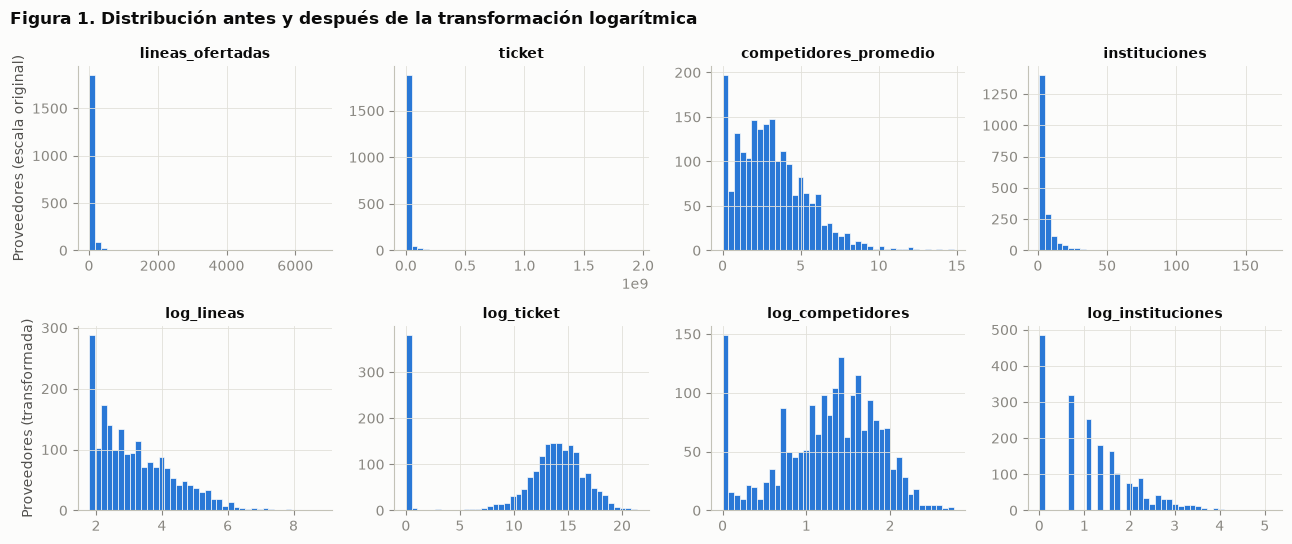

In [5]:
fig, ejes = plt.subplots(2, 4, figsize=(13, 5.5))
pares = [("lineas_ofertadas", "log_lineas"), ("ticket", "log_ticket"),
         ("competidores_promedio", "log_competidores"), ("instituciones", "log_instituciones")]
for col, (cruda, trans) in enumerate(pares):
    ejes[0, col].hist(crudas[cruda], bins=40, color=SERIE[0], edgecolor=SUPERFICIE, linewidth=0.5)
    ejes[0, col].set_title(cruda, fontsize=10)
    ejes[1, col].hist(X[trans], bins=40, color=SERIE[0], edgecolor=SUPERFICIE, linewidth=0.5)
    ejes[1, col].set_title(trans, fontsize=10)
ejes[0, 0].set_ylabel("Proveedores (escala original)")
ejes[1, 0].set_ylabel("Proveedores (transformada)")
fig.suptitle("Figura 1. Distribución antes y después de la transformación logarítmica",
             x=0.01, ha="left", fontweight="bold", color=TINTA)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig1_transformaciones.png", dpi=160)
plt.show()

In [6]:
escalador = StandardScaler()
Z = escalador.fit_transform(X)
X.corr().round(2)

,log_lineas,log_segmentos,log_instituciones,tasa_exito,log_competidores,log_precio_rel,log_ticket
log_lineas,1.000,0.640,0.550,-0.070,0.100,0.020,0.150
log_segmentos,0.640,1.000,0.520,-0.130,0.200,0.000,0.160
log_instituciones,0.550,0.520,1.000,-0.070,0.200,-0.020,0.340
tasa_exito,-0.070,-0.130,-0.070,1.000,-0.670,-0.070,0.510
log_competidores,0.100,0.200,0.200,-0.670,1.000,-0.020,-0.240
log_precio_rel,0.020,0.000,-0.020,-0.070,-0.020,1.000,-0.040
log_ticket,0.150,0.160,0.340,0.510,-0.240,-0.040,1.000


Las correlaciones más altas (volumen, segmentos e instituciones, 0,5–0,65) son
esperables: quien oferta más, lo hace en más mercados. No superan 0,7, así que se
mantienen las tres; juntas describen la *amplitud* del proveedor.

## 3. Elección del algoritmo y del número de grupos

**KMeans** porque: las variables son continuas y quedan escaladas; el objetivo es un
número pequeño de perfiles interpretables (centroides = "proveedor típico" de cada
grupo) que se puedan mostrar en la aplicación; y asigna cualquier proveedor nuevo al
centroide más cercano, lo que permite usarlo en producción. Alternativas
consideradas: DBSCAN (no produce perfiles comparables y marca como ruido a los
proveedores atípicos, que son justamente los grandes) y clustering jerárquico
(O(n²) en memoria, sin ventaja interpretativa aquí).

Se evalúa k = 2…8 con cuatro criterios: inercia (codo), coeficiente de silueta
(↑), índice de Davies-Bouldin (↓) y **estabilidad** (ARI medio entre la solución
con semilla 42 y tres semillas distintas; 1 = misma partición).

In [7]:
filas = []
modelos = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=20, random_state=SEMILLA).fit(Z)
    modelos[k] = km
    ari = np.mean([adjusted_rand_score(km.labels_,
                   KMeans(n_clusters=k, n_init=20, random_state=s).fit(Z).labels_)
                   for s in (1, 2, 3)])
    filas.append({"k": k, "inercia": km.inertia_,
                  "silueta": silhouette_score(Z, km.labels_),
                  "davies_bouldin": davies_bouldin_score(Z, km.labels_),
                  "estabilidad_ARI": ari,
                  "tamaño_min": np.bincount(km.labels_).min()})
evaluacion = pd.DataFrame(filas).set_index("k")
evaluacion

,inercia,silueta,davies_bouldin,estabilidad_ARI,tamaño_min
k,,,,,
2,"10,900.754",0.203,1.617,0.997,692
3,"8,259.177",0.274,1.344,0.998,413
4,"6,901.219",0.260,1.369,0.995,385
5,"6,257.959",0.268,1.252,1.000,49
6,"5,786.131",0.253,1.362,0.995,48
7,"5,356.345",0.261,1.279,0.993,27
8,"5,021.320",0.237,1.342,0.985,27


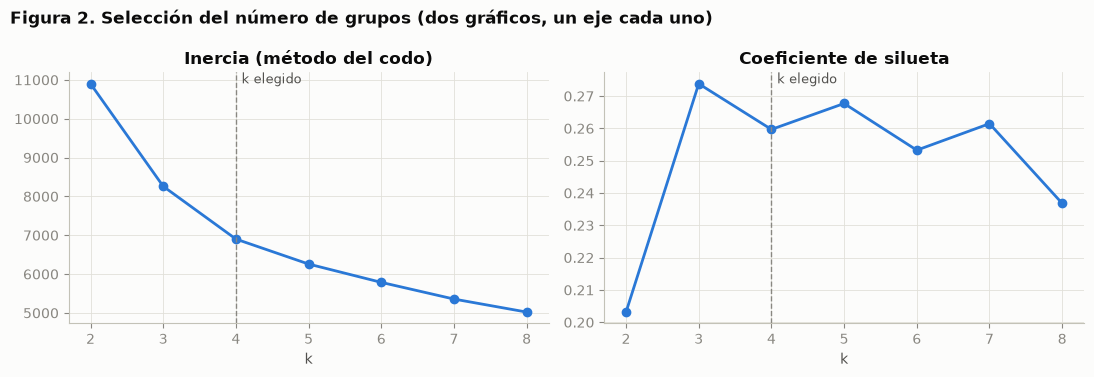

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(evaluacion.index, evaluacion["inercia"], color=SERIE[0], lw=2, marker="o", ms=6)
a1.set_title("Inercia (método del codo)")
a1.set_xlabel("k")
a2.plot(evaluacion.index, evaluacion["silueta"], color=SERIE[0], lw=2, marker="o", ms=6)
a2.set_title("Coeficiente de silueta")
a2.set_xlabel("k")
for eje in (a1, a2):
    eje.axvline(4, color=TINTA_SUAVE, lw=1, ls="--")
    eje.annotate("k elegido", (4, eje.get_ylim()[1]), xytext=(4.1, 0), textcoords="offset points",
                 color=TINTA_2, va="top", fontsize=9)
fig.suptitle("Figura 2. Selección del número de grupos (dos gráficos, un eje cada uno)",
             x=0.01, ha="left", fontweight="bold", color=TINTA)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig2_seleccion_k.png", dpi=160)
plt.show()

**Decisión: k = 4.** k = 3 tiene la silueta máxima (0,27) pero la diferencia con
k = 4 es de apenas 0,01 — ambas son estructuras de fuerza moderada (0,25–0,5), algo
esperable en datos de comportamiento que forman un continuo. k = 4 se elige por
**utilidad para el caso de uso**: separa un grupo de *proveedores de nicho* (ganan
casi todo lo que ofertan, con menos de un competidor por línea) que en k = 3 queda
mezclado con los ganadores de alto volumen. La partición es estable (ARI ≥ 0,98) y
el grupo más pequeño tiene cientos de proveedores. k ≥ 5 genera grupos de < 50
proveedores (atípicos de precio) sin lectura de negocio nueva.

In [9]:
K = 4
km = modelos[K]
pob["cluster_crudo"] = km.labels_

# Nombres de negocio asignados a partir de los centroides (ver tabla siguiente).
# Se asignan por reglas sobre los centroides y no por número de cluster, para que
# el nombre no dependa del orden arbitrario que devuelve KMeans.
centroides = pd.DataFrame(escalador.inverse_transform(km.cluster_centers_), columns=X.columns)
orden = {}
orden[centroides["log_lineas"].idxmax()] = "Generalistas de alto volumen"
restantes = [i for i in centroides.index if i not in orden]
orden[centroides.loc[restantes, "tasa_exito"].idxmin()] = "Sin adjudicaciones"
restantes = [i for i in centroides.index if i not in orden]
orden[centroides.loc[restantes, "log_competidores"].idxmin()] = "Nicho con poca competencia"
restantes = [i for i in centroides.index if i not in orden]
orden[restantes[0]] = "Competidores focalizados"
NOMBRES = ["Generalistas de alto volumen", "Competidores focalizados",
           "Nicho con poca competencia", "Sin adjudicaciones"]
pob["segmento_proveedor"] = pd.Categorical(pob["cluster_crudo"].map(orden), NOMBRES, ordered=True)

perfil = pob.groupby("segmento_proveedor", observed=True).agg(
    proveedores=("cedula_proveedor", "size"),
    lineas_ofertadas_mediana=("lineas_ofertadas", "median"),
    segmentos_mediana=("segmentos", "median"),
    instituciones_mediana=("instituciones", "median"),
    tasa_exito_mediana=("tasa_exito", "median"),
    competidores_mediana=("competidores_promedio", "median"),
    precio_relativo_mediana=("precio_rel", "median"),
    ticket_mediana_crc=("ticket", "median"),
    monto_total_crc=("monto_adjudicado_crc", "sum"),
)
perfil["%_monto_adjudicado"] = perfil["monto_total_crc"] / perfil["monto_total_crc"].sum()
perfil

,proveedores,lineas_ofertadas_mediana,segmentos_mediana,instituciones_mediana,tasa_exito_mediana,competidores_mediana,precio_relativo_mediana,ticket_mediana_crc,monto_total_crc,%_monto_adjudicado
segmento_proveedor,,,,,,,,,,
Generalistas de alto volumen,450,104.000,7.000,10.000,0.332,3.133,1.000,"846,043.820","85,476,806,861.975",0.406
Competidores focalizados,653,16.000,2.000,4.000,0.280,3.571,1.000,"2,443,264.523","71,123,904,780.103",0.338
Nicho con poca competencia,502,11.000,2.000,2.000,1.000,0.718,1.000,"1,217,972.221","52,988,651,342.190",0.252
Sin adjudicaciones,385,10.000,2.000,1.000,0.000,4.000,1.000,0.000,"908,946,139.264",0.004


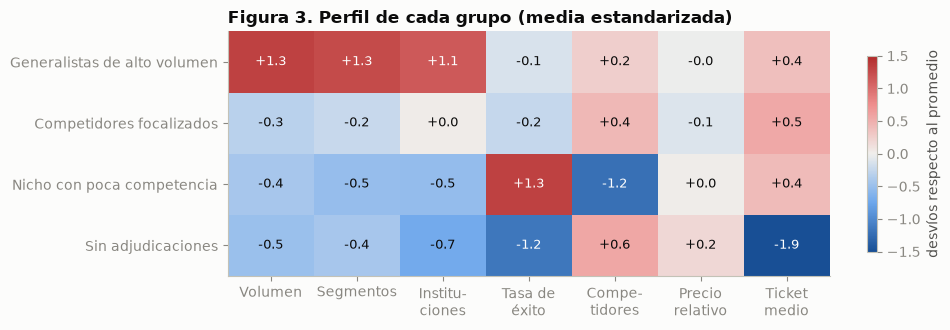

In [10]:
# Perfil estandarizado de cada grupo: media de cada variable escalada (z).
# Divergente azul-rojo con punto medio gris: 0 = promedio de la población.
from matplotlib.colors import LinearSegmentedColormap
divergente = LinearSegmentedColormap.from_list(
    "azul_rojo", ["#184f95", "#6da7ec", "#f0efec", "#ef8f8e", "#b02a2a"])
z_medias = pd.DataFrame(Z, columns=X.columns, index=pob.index) \
    .groupby(pob["segmento_proveedor"], observed=True).mean()
etiquetas = {"log_lineas": "Volumen", "log_segmentos": "Segmentos", "log_instituciones": "Institu-\nciones",
             "tasa_exito": "Tasa de\néxito", "log_competidores": "Compe-\ntidores",
             "log_precio_rel": "Precio\nrelativo", "log_ticket": "Ticket\nmedio"}
fig, eje = plt.subplots(figsize=(10, 3.4))
im = eje.imshow(z_medias.values, cmap=divergente, vmin=-1.5, vmax=1.5, aspect="auto")
eje.set_xticks(range(len(z_medias.columns)), [etiquetas[c] for c in z_medias.columns])
eje.set_yticks(range(len(z_medias.index)), z_medias.index)
eje.grid(False)
for i in range(z_medias.shape[0]):
    for j in range(z_medias.shape[1]):
        v = z_medias.iat[i, j]
        eje.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=9,
                 color="#ffffff" if abs(v) > 0.9 else TINTA)
fig.colorbar(im, ax=eje, shrink=0.8, label="desvíos respecto al promedio")
eje.set_title("Figura 3. Perfil de cada grupo (media estandarizada)", loc="left")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig3_perfil_grupos.png", dpi=160)
plt.show()

## 4. Visualización con PCA

Reducción de dimensionalidad solo para **visualizar** (el clustering se hizo en las
7 dimensiones). Con 4 grupos, un único gráfico de dispersión a color no garantiza
distinguibilidad para personas con daltonismo (la paleta valida hasta 3 colores
en dispersión), así que se usan **pequeños múltiplos**: cada panel resalta un
grupo sobre el resto en gris.

Varianza explicada: [0.33  0.279] · total 0.61
                     CP1    CP2
log_lineas         0.530  0.130
log_segmentos      0.550  0.080
log_instituciones  0.530  0.160
tasa_exito        -0.200  0.620
log_competidores   0.280 -0.510
log_precio_rel     0.000 -0.060
log_ticket         0.130  0.550


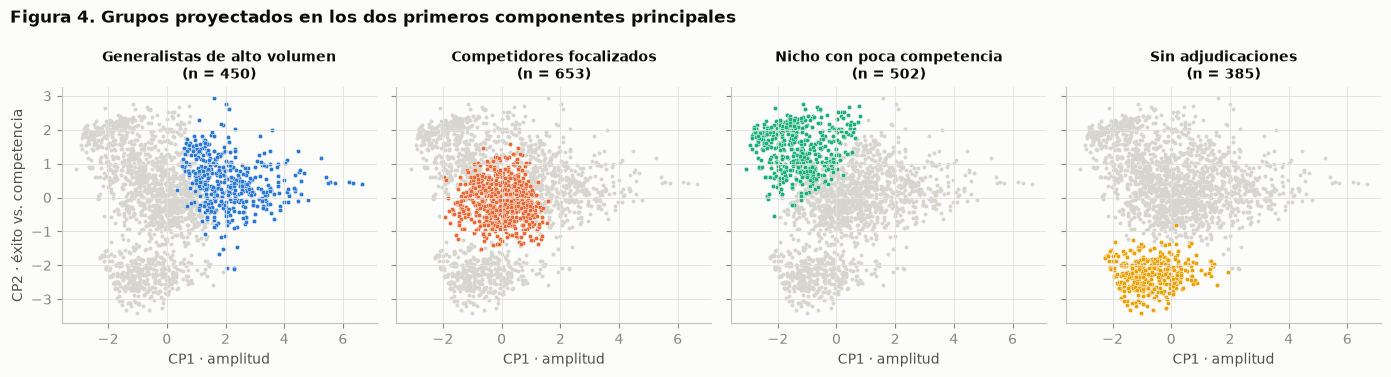

In [11]:
pca = PCA(n_components=2, random_state=SEMILLA)
P = pca.fit_transform(Z)
print("Varianza explicada:", pca.explained_variance_ratio_.round(3),
      "· total", pca.explained_variance_ratio_.sum().round(3))
cargas = pd.DataFrame(pca.components_.T, index=X.columns, columns=["CP1", "CP2"])
print(cargas.round(2))

fig, ejes = plt.subplots(1, 4, figsize=(14, 3.8), sharex=True, sharey=True)
for eje, nombre, color in zip(ejes, NOMBRES, SERIE):
    m = (pob["segmento_proveedor"] == nombre).values
    eje.scatter(P[~m, 0], P[~m, 1], s=8, color=GRIS_FONDO, lw=0)
    eje.scatter(P[m, 0], P[m, 1], s=10, color=color, lw=0.3, edgecolor=SUPERFICIE)
    eje.set_title(f"{nombre}\n(n = {m.sum():,})", fontsize=10)
    eje.set_xlabel("CP1 · amplitud")
ejes[0].set_ylabel("CP2 · éxito vs. competencia")
fig.suptitle("Figura 4. Grupos proyectados en los dos primeros componentes principales",
             x=0.01, ha="left", fontweight="bold", color=TINTA)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig4_pca_grupos.png", dpi=160)
plt.show()

## 5. ¿El tamaño de empresa explica los grupos?

El tamaño (`tamano_proveedor`) **no** se usó para formar los grupos: se reserva
para validar externamente la segmentación y responder una pregunta del TFM: ¿las
MIPYMES se comportan distinto de las grandes?

tamano_proveedor,Microemprendedor,Pequeña,Mediana,Grande
segmento_proveedor,,,,
Generalistas de alto volumen,13%,38%,26%,23%
Competidores focalizados,17%,42%,24%,18%
Nicho con poca competencia,16%,37%,25%,22%
Sin adjudicaciones,18%,44%,21%,17%


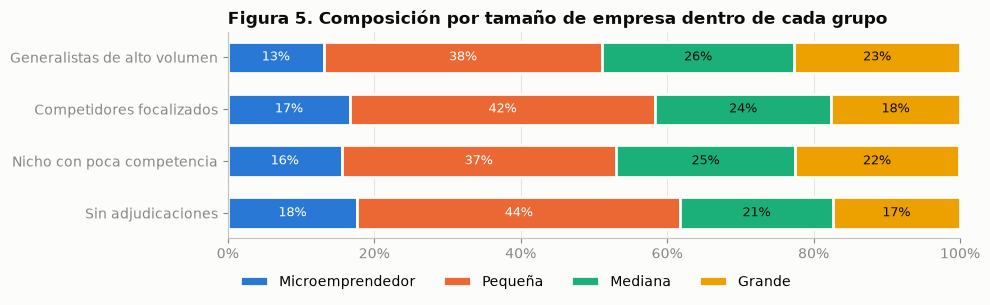

chi² = 15.3, gl = 9, p = 0.082, V de Cramér = 0.051


In [12]:
ORDEN_TAMANO = ["Microemprendedor", "Pequeña", "Mediana", "Grande"]
comp = pd.crosstab(pob["segmento_proveedor"], pob["tamano_proveedor"], normalize="index")
comp = comp.reindex(columns=ORDEN_TAMANO).fillna(0)
display(comp.style.format("{:.0%}"))

fig, eje = plt.subplots(figsize=(10, 3.2))
izquierda = np.zeros(len(comp))
for j, tam in enumerate(ORDEN_TAMANO):
    eje.barh(comp.index.astype(str), comp[tam], left=izquierda, color=SERIE[j],
             edgecolor=SUPERFICIE, linewidth=2, label=tam, height=0.6)
    for i, v in enumerate(comp[tam]):
        if v >= 0.08:
            eje.text(izquierda[i] + v / 2, i, f"{v:.0%}", ha="center", va="center",
                     fontsize=9, color="#ffffff" if j in (0, 1) else TINTA)
    izquierda += comp[tam].values
eje.invert_yaxis()
eje.set_axisbelow(True)
eje.set_xlim(0, 1)
eje.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
eje.grid(axis="y", visible=False)
eje.legend(ncols=4, loc="upper left", bbox_to_anchor=(0, -0.12))
eje.set_title("Figura 5. Composición por tamaño de empresa dentro de cada grupo", loc="left")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig5_tamano_por_grupo.png", dpi=160)
plt.show()

# Contraste chi-cuadrado de independencia entre grupo y tamaño.
from scipy.stats import chi2_contingency
tabla = pd.crosstab(pob["segmento_proveedor"], pob["tamano_proveedor"]).reindex(columns=ORDEN_TAMANO).fillna(0)
chi2, p, gl, _ = chi2_contingency(tabla)
v_cramer = np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1)))
print(f"chi² = {chi2:.1f}, gl = {gl}, p = {p:.3g}, V de Cramér = {v_cramer:.3f}")

## 6. Hipótesis 3: mapa de oportunidades por segmento de producto

Complemento a nivel de **mercado**: para cada segmento UNSPSC se cruza la demanda
(líneas publicadas) con la competencia (ofertas por línea) y el porcentaje de
líneas publicadas que no recibieron ninguna oferta. Un segmento con mucha demanda y
poca competencia es un candidato a "área desatendida".

**Nota de cobertura (hallazgo de calidad de datos).** En la versión del
`sicop.duckdb` usada (release del 24/09/2026) solo ~12 % de los procedimientos de
`fact_lineas_carteles` tienen alguna oferta en `fact_lineas_ofertas` (la celda
siguiente lo cuantifica por mes). Si se usaran todos los carteles, "sin ofertas"
mediría la falta de datos y no la falta de competencia. Por eso el análisis se
restringe a los procedimientos **con cobertura de ofertas**, y el hallazgo se
reporta al responsable del pipeline.

In [13]:
cobertura = con.execute('''
    SELECT strftime(fecha_publicacion, '%Y-%m') AS mes,
           COUNT(DISTINCT c.nro_sicop) AS procedimientos,
           COUNT(DISTINCT c.nro_sicop) FILTER (WHERE o.nro_sicop IS NOT NULL) AS con_ofertas
    FROM final.fact_lineas_carteles c
    LEFT JOIN (SELECT DISTINCT nro_sicop FROM final.fact_lineas_ofertas) o USING (nro_sicop)
    GROUP BY 1 ORDER BY 1
''').df()
cobertura["cobertura"] = cobertura["con_ofertas"] / cobertura["procedimientos"]
print(f"Cobertura global: {cobertura['con_ofertas'].sum() / cobertura['procedimientos'].sum():.1%}")
cobertura

Cobertura global: 12.3%


,mes,procedimientos,con_ofertas,cobertura
0,2025-01,1000,230,0.230
1,2025-02,2165,675,0.312
2,2025-03,3005,887,0.295
3,2025-04,2528,681,0.269
4,2025-05,3303,525,0.159
5,2025-06,3232,516,0.160
6,2025-07,3016,331,0.110
7,2025-08,3069,362,0.118
8,2025-09,3240,207,0.064
9,2025-10,4371,299,0.068


In [14]:
mercado = con.execute('''
    WITH ofertas_linea AS (
        SELECT nro_sicop, nro_linea, COUNT(*) AS ofertas
        FROM final.fact_lineas_ofertas GROUP BY ALL
    )
    SELECT p.segmento, p.nombre_segmento,
           COUNT(*)                                            AS lineas_publicadas,
           AVG(COALESCE(o.ofertas, 0))                         AS ofertas_por_linea,
           AVG(CASE WHEN o.ofertas IS NULL THEN 1 ELSE 0 END)  AS pct_sin_ofertas
    FROM final.fact_lineas_carteles c
    JOIN final.dim_productos p ON p.cod_producto = TRY_CAST(c.cod_producto AS BIGINT)
    -- solo procedimientos con cobertura en la tabla de ofertas (ver nota de cobertura)
    JOIN (SELECT DISTINCT nro_sicop FROM final.fact_lineas_ofertas) cov USING (nro_sicop)
    LEFT JOIN ofertas_linea o ON o.nro_sicop = c.nro_sicop AND o.nro_linea = c.numero_linea
    GROUP BY ALL
    HAVING COUNT(*) >= 100
    ORDER BY lineas_publicadas DESC
''').df()
med_dem, med_comp = mercado["lineas_publicadas"].median(), mercado["ofertas_por_linea"].median()
mercado["oportunidad"] = (mercado["lineas_publicadas"] >= med_dem) & (mercado["ofertas_por_linea"] <= med_comp)
print(f"Segmentos analizados: {len(mercado)} · mediana de demanda {med_dem:,.0f} líneas · "
      f"mediana de competencia {med_comp:.2f} ofertas/línea")
mercado[mercado["oportunidad"]].sort_values("lineas_publicadas", ascending=False)

Segmentos analizados: 45 · mediana de demanda 756 líneas · mediana de competencia 2.46 ofertas/línea


,segmento,nombre_segmento,lineas_publicadas,ofertas_por_linea,pct_sin_ofertas,oportunidad
0,42,"Equipo médico, accesorios e insumos",3329,2.014,0.068,True
2,78,"Servicios de transporte, almacenamiento y correo",2370,1.449,0.007,True
3,41,"Instrumentos de laboratorio, medición y observ...",2325,2.362,0.057,True
4,55,"Publicaciones, grabaciones y medios de informa...",2274,2.015,0.077,True
9,81,"Servicios de ingeniería, investigación y tecno...",1512,1.481,0.063,True
10,86,Servicios de educación y formación,1454,1.593,0.039,True
14,90,"Servicios de viaje, alimentación y alojamiento",1299,1.833,0.097,True
16,80,Servicios profesionales de gestión y administr...,1155,2.144,0.047,True
18,82,Servicios editoriales y gráficos,905,2.455,0.075,True
20,73,Servicios de manufactura industrial,881,2.316,0.166,True


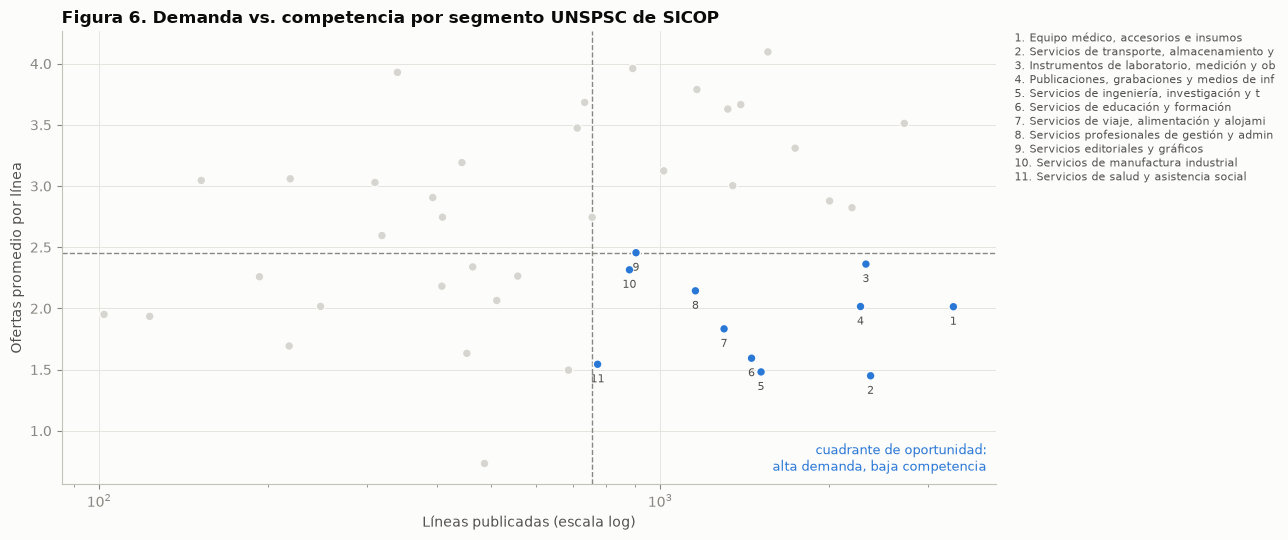

In [15]:
fig, eje = plt.subplots(figsize=(13, 5.5))
eje.scatter(mercado["lineas_publicadas"], mercado["ofertas_por_linea"], s=40,
            color=np.where(mercado["oportunidad"], SERIE[0], GRIS_FONDO),
            edgecolor=SUPERFICIE, lw=1, zorder=3)
eje.set_xscale("log")
eje.axvline(med_dem, color=TINTA_SUAVE, lw=1, ls="--")
eje.axhline(med_comp, color=TINTA_SUAVE, lw=1, ls="--")
# Etiquetas numeradas (el nombre completo va en la tabla de arriba) para evitar
# que los nombres largos de segmento se superpongan.
candidatos = mercado[mercado["oportunidad"]].sort_values("lineas_publicadas", ascending=False)
for n, (_, f) in enumerate(candidatos.iterrows(), start=1):
    eje.annotate(str(n), (f["lineas_publicadas"], f["ofertas_por_linea"]),
                 xytext=(0, -13), textcoords="offset points", ha="center",
                 fontsize=8, color=TINTA_2)
leyenda = "\n".join(f"{n}. {nom[:42]}" for n, nom in enumerate(candidatos["nombre_segmento"], start=1))
eje.text(1.02, 1.0, leyenda, transform=eje.transAxes, va="top", fontsize=8, color=TINTA_2)
eje.text(0.99, 0.02, "cuadrante de oportunidad:\nalta demanda, baja competencia",
         transform=eje.transAxes, ha="right", va="bottom", fontsize=9, color=SERIE[0])
eje.set_xlabel("Líneas publicadas (escala log)")
eje.set_ylabel("Ofertas promedio por línea")
eje.set_title("Figura 6. Demanda vs. competencia por segmento UNSPSC de SICOP", loc="left")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig6_mapa_oportunidades.png", dpi=160)
plt.show()

## 7. Análisis complementarios

### 7.1 Diagrama de silueta (validación de la partición)

La silueta media resume la calidad global; el diagrama muestra **cada proveedor**:
valores negativos indican proveedores que quedarían mejor en otro grupo. Permite ver
si algún grupo es débil o si el problema está repartido.

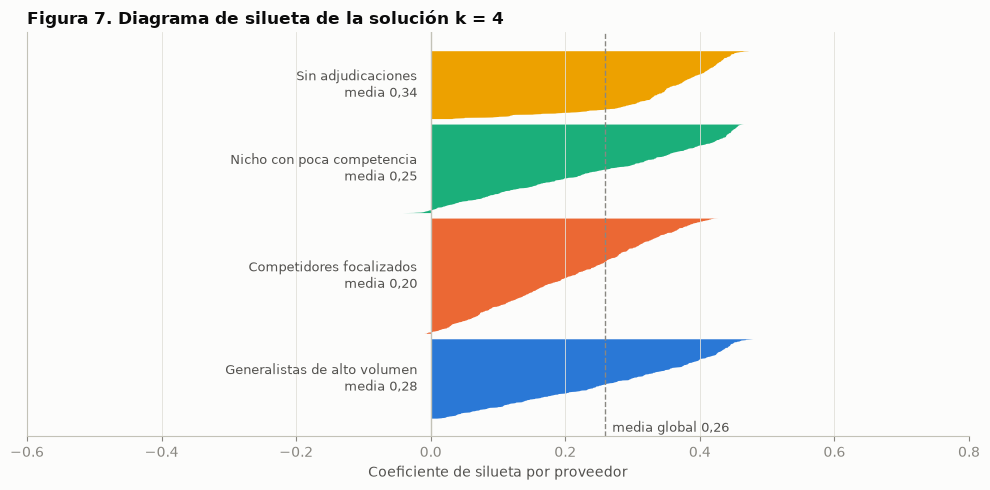

,media,pct_negativos
segmento_proveedor,,
Generalistas de alto volumen,0.275,0.000
Competidores focalizados,0.205,0.014
Nicho con poca competencia,0.252,0.032
Sin adjudicaciones,0.345,0.000


In [16]:
from sklearn.metrics import silhouette_samples
sil = silhouette_samples(Z, km.labels_)
pob["silueta"] = sil
fig, eje = plt.subplots(figsize=(10, 5))
y0 = 0
for nombre, color in zip(NOMBRES, SERIE):
    valores = np.sort(pob.loc[pob["segmento_proveedor"] == nombre, "silueta"].values)
    eje.fill_betweenx(np.arange(y0, y0 + len(valores)), 0, valores, color=color, lw=0)
    eje.text(-0.02, y0 + len(valores) / 2, f"{nombre}\nmedia {valores.mean():.2f}".replace(".", ","),
             ha="right", va="center", fontsize=9, color=TINTA_2)
    y0 += len(valores) + 30
eje.axvline(sil.mean(), color=TINTA_SUAVE, ls="--", lw=1)
eje.text(sil.mean() + 0.01, -15, f"media global {sil.mean():.2f}".replace(".", ","),
         fontsize=9, color=TINTA_2, va="top")
eje.axvline(0, color="#c3c2b7", lw=1)
eje.set_yticks([])
eje.set_xlim(-0.6, 0.8)
eje.set_xlabel("Coeficiente de silueta por proveedor")
eje.set_title("Figura 7. Diagrama de silueta de la solución k = 4", loc="left")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig7_silueta.png", dpi=160)
plt.show()
resumen_sil = pob.groupby("segmento_proveedor", observed=True)["silueta"].agg(
    media="mean", pct_negativos=lambda s: (s < 0).mean())
resumen_sil

### 7.2 Distribución de las variables clave por grupo

Las medianas de la tabla de perfiles no muestran la dispersión. Los diagramas de
caja permiten ver si los grupos se solapan en cada variable.

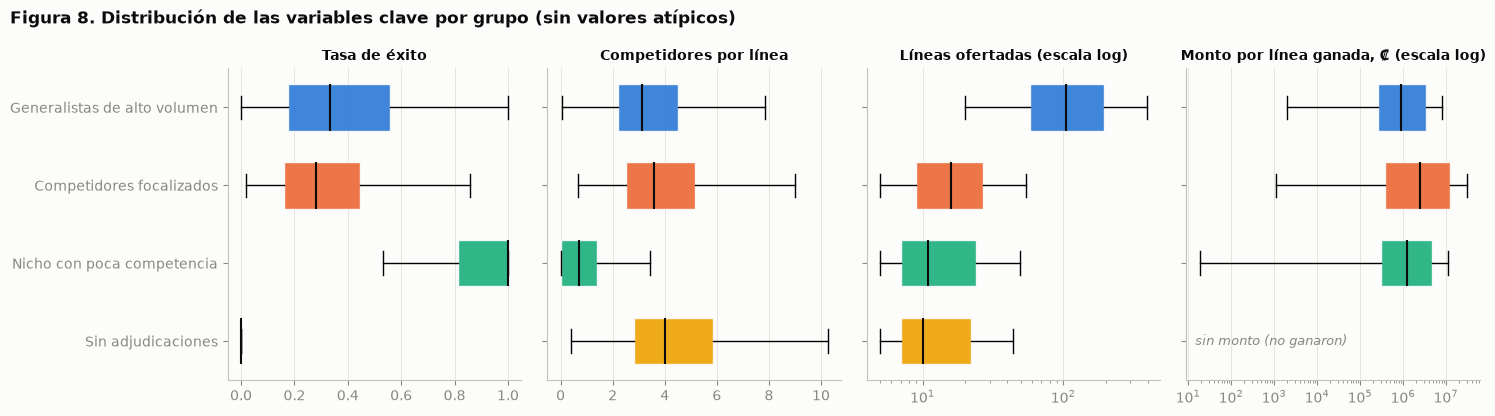

In [17]:
variables_caja = [("tasa_exito", "Tasa de éxito", False),
                  ("competidores_promedio", "Competidores por línea", False),
                  ("lineas_ofertadas", "Líneas ofertadas (escala log)", True),
                  ("ticket", "Monto por línea ganada, ₡ (escala log)", True)]
fig, ejes = plt.subplots(1, 4, figsize=(15, 4.2))
for eje, (col, titulo, logaritmo) in zip(ejes, variables_caja):
    datos_caja = [pob.loc[pob["segmento_proveedor"] == n, col].values for n in NOMBRES]
    if logaritmo:
        # En escala log solo caben valores > 0. Si a un grupo le quedan pocos (p. ej. los
        # «Sin adjudicaciones» no tienen monto), una caja con esos pocos engañaría:
        # se omite y se escribe el motivo.
        positivos = [v[v > 0] for v in datos_caja]
        omitidos = [len(p) < 0.5 * len(v) for p, v in zip(positivos, datos_caja)]
        datos_caja = [p if not o else [] for p, o in zip(positivos, omitidos)]
    else:
        omitidos = [False] * 4
    cajas = eje.boxplot(datos_caja, orientation="horizontal", patch_artist=True, widths=0.6,
                        showfliers=False, medianprops={"color": TINTA, "lw": 1.5})
    for caja, color in zip(cajas["boxes"], SERIE):
        caja.set(facecolor=color, edgecolor=SUPERFICIE, alpha=0.9)
    if logaritmo:
        eje.set_xscale("log")
    for i, o in enumerate(omitidos, start=1):
        if o:
            eje.text(0.03, i, "sin monto (no ganaron)", transform=eje.get_yaxis_transform(),
                     va="center", fontsize=9, color=TINTA_SUAVE, style="italic")
    eje.set_title(titulo, fontsize=10)
    eje.set_yticks(range(1, 5), NOMBRES if eje is ejes[0] else [""] * 4)
    eje.invert_yaxis()
    eje.grid(axis="y", visible=False)
fig.suptitle("Figura 8. Distribución de las variables clave por grupo (sin valores atípicos)",
             x=0.01, ha="left", fontweight="bold", color=TINTA)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig8_cajas_por_grupo.png", dpi=160)
plt.show()

### 7.3 ¿Gana siempre la oferta más barata?

Nivel **línea**. En las líneas resueltas con al menos dos ofertas con precio, se
ordena el precio de las ofertas (1 = la más barata) y se mira en qué posición estaba
la oferta adjudicada. Si el precio fuera el único criterio, casi todo caería en la
posición 1. La diferencia es el espacio de la **Compra Pública Estratégica** (marco
teórico): criterios técnicos, sociales o el «criterio PYME» pesan en la adjudicación.
Para el proveedor, significa que bajar el precio no basta y que la información sobre
cómo adjudica cada institución tiene valor.

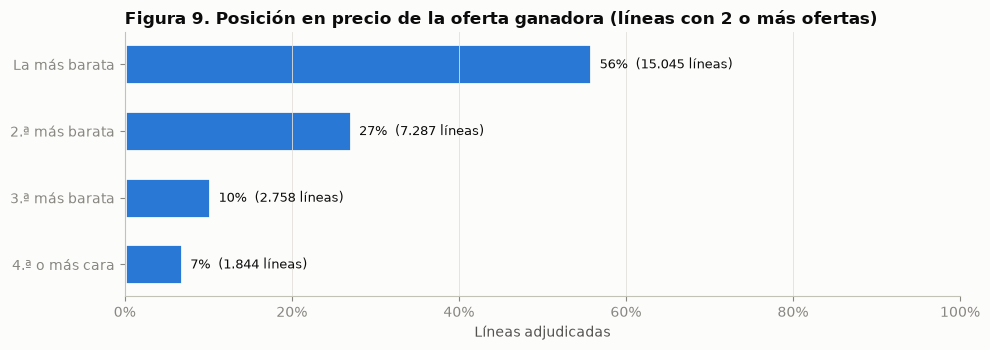

,posicion,lineas,porcentaje
0,1,15045,0.559
1,2,7287,0.271
2,3,2758,0.102
3,4,1844,0.068


In [18]:
posicion_ganador = con.execute(f'''
    WITH ofertas AS (
        SELECT nro_sicop, nro_linea, cedula_proveedor,
               CASE WHEN tipo_moneda = 'CRC' THEN precio_unitario_ofertado
                    WHEN tipo_moneda = 'USD' AND tipo_cambio_crc > 0
                         THEN precio_unitario_ofertado * tipo_cambio_crc END AS precio_crc
        FROM final.fact_lineas_ofertas
        WHERE precio_unitario_ofertado > 0
    ),
    rank_lineas AS (
        SELECT *, RANK() OVER (PARTITION BY nro_sicop, nro_linea ORDER BY precio_crc) AS posicion,
               COUNT(*) OVER (PARTITION BY nro_sicop, nro_linea) AS n_ofertas
        FROM ofertas WHERE precio_crc IS NOT NULL
    ),
    ganadores AS (SELECT DISTINCT nro_sicop, nro_linea, cedula_proveedor FROM final.fact_lineas_adjudicadas)
    SELECT LEAST(r.posicion, 4) AS posicion, COUNT(*) AS lineas
    FROM rank_lineas r
    JOIN ganadores g USING (nro_sicop, nro_linea, cedula_proveedor)
    WHERE r.n_ofertas >= 2
    GROUP BY 1 ORDER BY 1
''').df()
posicion_ganador["porcentaje"] = posicion_ganador["lineas"] / posicion_ganador["lineas"].sum()
etiquetas_pos = {1: "La más barata", 2: "2.ª más barata", 3: "3.ª más barata", 4: "4.ª o más cara"}

fig, eje = plt.subplots(figsize=(10, 3.6))
y = range(len(posicion_ganador))
eje.barh(y, posicion_ganador["porcentaje"], color=SERIE[0], height=0.6, edgecolor=SUPERFICIE, lw=2)
for yi, v, n in zip(y, posicion_ganador["porcentaje"], posicion_ganador["lineas"]):
    eje.text(v + 0.01, yi, f"{v:.0%}  ({n:,} líneas)".replace(",", "."), va="center", fontsize=9, color=TINTA)
eje.set_yticks(list(y), [etiquetas_pos[int(p)] for p in posicion_ganador["posicion"]])
eje.invert_yaxis()
eje.set_xlim(0, 1)
eje.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
eje.grid(axis="y", visible=False)
eje.set_xlabel("Líneas adjudicadas")
eje.set_title("Figura 9. Posición en precio de la oferta ganadora (líneas con 2 o más ofertas)", loc="left")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig9_posicion_precio_ganador.png", dpi=160)
plt.show()
posicion_ganador

## 8. Exportación para la aplicación (UC2)

Se guardan el escalador y el modelo KMeans (para asignar un proveedor nuevo a su
grupo) y la asignación de cada proveedor, que lee la página «Caracterización de
proveedores» de la aplicación Streamlit.

In [19]:
import joblib
salida = Path("../app/datos")
salida.mkdir(parents=True, exist_ok=True)
pob[["cedula_proveedor", "segmento_proveedor", "lineas_ofertadas", "lineas_resueltas",
     "lineas_ganadas", "tasa_exito", "competidores_promedio", "precio_rel", "ticket",
     "segmentos", "instituciones", "monto_adjudicado_crc", "tamano_proveedor"]] \
    .assign(segmento_proveedor=lambda d: d["segmento_proveedor"].astype(str)) \
    .to_parquet(salida / "segmentos_proveedores.parquet", index=False)
mercado.to_parquet(salida / "mapa_oportunidades.parquet", index=False)
joblib.dump({"escalador": escalador, "kmeans": km, "nombres": orden,
             "variables": list(X.columns)}, salida / "segmentacion_kmeans.joblib")
print(sorted(p.name for p in salida.iterdir()))

['mapa_oportunidades.parquet', 'segmentacion_kmeans.joblib', 'segmentos_proveedores.parquet']


## 9. Interpretación, relación con el TFM y limitaciones

Ver la sección escrita en la memoria (archivo `Seccion_Asig7_No_Supervisado.docx`),
que se redacta a partir de los resultados impresos arriba. Resumen:

* **Cuatro perfiles de comportamiento** con lectura de negocio directa para el
  benchmarking del UC2.
* **El tamaño de empresa casi no explica el perfil** (ver V de Cramér): el
  comportamiento en el mercado —dónde y contra quién se oferta— distingue más que
  ser MIPYME o grande. Argumento central del TFM: la brecha es de *información*, no
  de tamaño.
* **Hipótesis 3**: el grupo *Nicho con poca competencia* y el cuadrante de
  oportunidad de la Figura 6 son evidencia de espacios con poca competencia.
* **Limitaciones**: la tabla de ofertas cubre solo ~12 % de los procedimientos
  publicados en esta versión de los datos, por lo que los perfiles describen a los
  proveedores *observados*, no a todo el mercado; 20 meses de datos; la tasa de
  éxito depende del enlace oferta↔adjudicación (≈14 mil adjudicaciones sin oferta
  asociada); silueta moderada; las variables describen el pasado, no la capacidad
  de la empresa. Al corregirse la cobertura, basta volver a ejecutar el cuaderno.